In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.783431
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.777522
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.825769
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.889904


<Axes: >

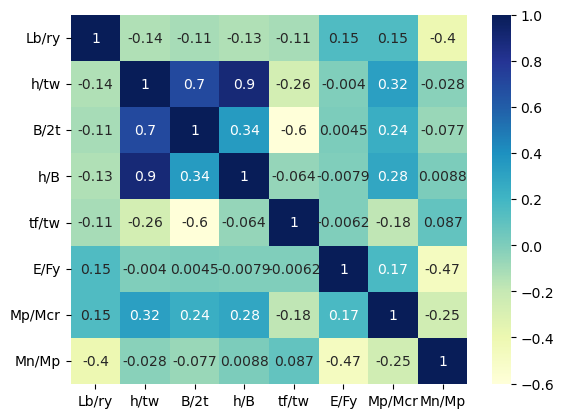

In [3]:
sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

In [4]:
df.describe()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
count,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000
mean,97.366596,34.963695,5.634730,1.853852,1.653545,248.937214,1.624280,0.726006
std,37.083167,14.070018,1.363515,0.583968,0.116217,40.796326,0.948242,0.192763
min,29.629630,10.100775,3.115942,0.885256,1.380000,208.279468,0.232590,0.203974
25%,68.441065,20.685393,4.491525,1.588288,1.597315,208.279468,0.905141,0.605143
50%,93.655589,36.729167,5.434783,1.911429,1.640351,208.279468,1.416495,0.747639
75%,120.786517,45.524476,6.826087,2.216407,1.730496,289.779767,2.146375,0.905529
max,247.734139,61.420000,7.971014,2.791818,1.903614,289.779767,5.694176,1.009362


(0.0, 1.0)

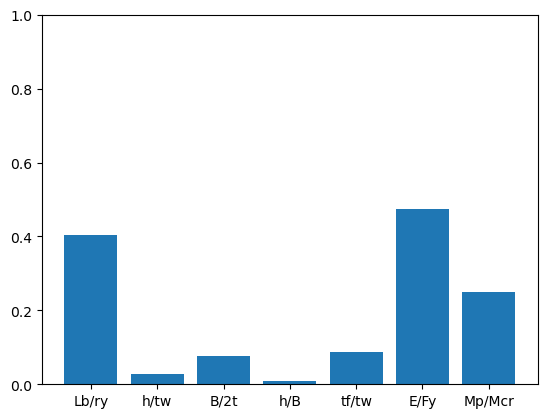

In [5]:
C = df.corr(numeric_only=True)['Mn/Mp'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

In [6]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.1, random_state=100)

In [8]:
def evaluate_pipeline(estimator, grid_params, search_method=GridSearchCV):
    if search_method != GridSearchCV:
        cv = search_method(estimator, grid_params, random_state=100)
    else:
        cv = search_method(estimator, grid_params)
    cv.fit(X_train, y_train)

    pipeline = cv.best_estimator_
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_mse = mean_squared_error(pipeline_test_prd, y_test)
    pipeline_test_mae = mean_absolute_error(pipeline_test_prd, y_test)
    pipeline_test_r2_score = r2_score(pipeline_test_prd, y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_mse = mean_squared_error(pipeline_full_prd, y_full)
    pipeline_full_mae = mean_absolute_error(pipeline_full_prd, y_full)
    pipeline_full_r2_score = r2_score(pipeline_full_prd, y_full)
    
    metrics = {
        'test_mse': pipeline_test_mse,
        'test_mae': pipeline_test_mae,
        'test_r2': pipeline_test_r2_score,
        'full_mse': pipeline_full_mse,
        'full_mae': pipeline_full_mae,
        'full_r2': pipeline_full_r2_score,
    }

    return pipeline, pd.DataFrame(cv.cv_results_), metrics

In [9]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [150, 200, 250, 300],
}

_, _, rf_metrics = evaluate_pipeline(RandomForestRegressor(random_state=42), rf_params)

rf_metrics

{'test_mse': 0.0039417884753931865,
 'test_mae': 0.04033925587051848,
 'test_r2': 0.910173128456926,
 'full_mse': 0.0007337927701785185,
 'full_mae': 0.014407832191730873,
 'full_r2': 0.9785337877712665}

In [10]:
gb_params = {
    'criterion' : ['squared_error', 'friedman_mse'],
    'n_estimators' : [150, 200, 250, 300],
}

_, _, gb_metrics = evaluate_pipeline(GradientBoostingRegressor(random_state=42), gb_params)

gb_metrics

{'test_mse': 0.005820604367044598,
 'test_mae': 0.05288127582805038,
 'test_r2': 0.8536349982958803,
 'full_mse': 0.0013425003132873342,
 'full_mae': 0.024347079528137656,
 'full_r2': 0.9593998166902156}

In [11]:
from sklearn.svm import SVR
from scipy.stats import loguniform, uniform

svr_params = {
    'C': loguniform(1, 1e2),
    'epsilon': uniform(0.01, 0.1),
    'gamma': loguniform(1e-3, 1e3)
}

_, _, svr_metrics = evaluate_pipeline(SVR(), svr_params, RandomizedSearchCV)

svr_metrics

{'test_mse': 0.006550156233325628,
 'test_mae': 0.056220462373809524,
 'test_r2': 0.8415128204403699,
 'full_mse': 0.0023345016787623776,
 'full_mae': 0.03468465370159011,
 'full_r2': 0.9280496275293147}

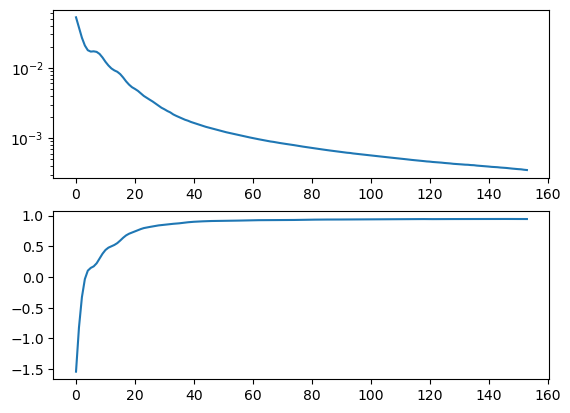

{'test_mse': 0.0036722442691033566,
 'test_mae': 0.03906848987366366,
 'test_r2': 0.9163939195582546,
 'full_mse': 0.0011241715563297834,
 'full_mae': 0.019209341167817133,
 'full_r2': 0.9680391657648946}

In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(16, 16, 16, 16), (32, 32, 32, 32), (64, 64)],
    'mlp__activation' : ['relu', 'tanh'],
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=500))
])

nn_pipeline, _, nn_metrics = evaluate_pipeline(nn_pipeline, nn_params)

plt.subplot(2, 1, 1)
plt.semilogy(nn_pipeline['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(nn_pipeline['mlp'].validation_scores_)
plt.show()


nn_metrics

In [13]:
metrics = pd.DataFrame({
    'RFR' : rf_metrics,
    'XGB' : gb_metrics,
    'SVR' : svr_metrics,
    'MLP' : nn_metrics,
})

metrics

,RFR,XGB,SVR,MLP
test_mse,0.003942,0.005821,0.006550,0.003672
test_mae,0.040339,0.052881,0.056220,0.039068
test_r2,0.910173,0.853635,0.841513,0.916394
full_mse,0.000734,0.001343,0.002335,0.001124
full_mae,0.014408,0.024347,0.034685,0.019209
full_r2,0.978534,0.959400,0.928050,0.968039


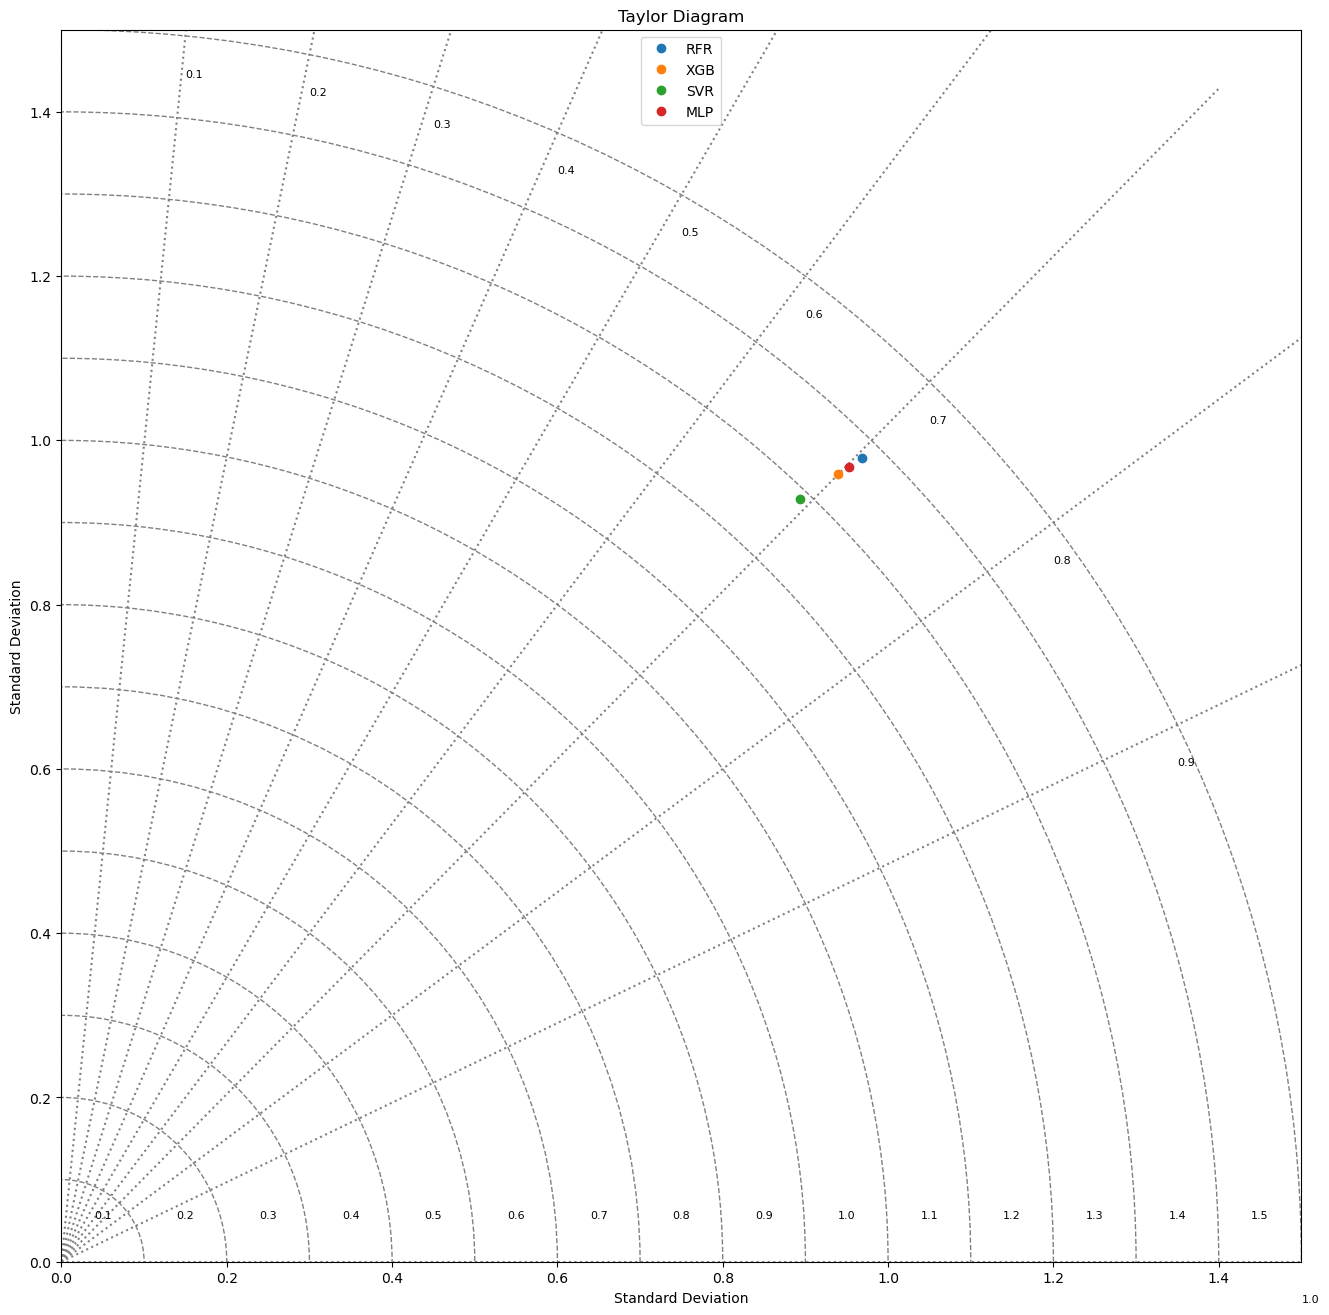

In [14]:
def draw_taylor_diagram_from_dataframe(metrics_df):
    """
    Draws a Taylor diagram from a pandas DataFrame of metrics.

    Args:
        metrics_df: A pandas DataFrame where columns are model names and rows are metrics.
    """

    # Extract metrics for Taylor diagram
    model_names = metrics_df.columns.tolist()
    standard_deviations = metrics_df.loc['full_r2'].apply(lambda x: x**0.5).tolist() # r2 as proxy
    correlation_coefficients = metrics_df.loc['full_r2'].tolist() #r2 as proxy
    centered_rms_diffs = metrics_df.loc['full_mse'].apply(lambda x: x**0.5).tolist() #mse as proxy

    # Create Taylor diagram
    fig, ax = plt.subplots(figsize=(16, 16))

    # Draw arcs for standard deviation
    std_ticks = np.arange(0.1, 1.51, 0.1)  # Adjust as needed
    for std in std_ticks:
        circle = plt.Circle((0, 0), std, fill=False, linestyle='--', color='gray')
        ax.add_artist(circle)
        ax.text(std - 0.05, 0.05, f'{std:.1f}', ha='center', va='bottom', fontsize=8)

    # Draw radial lines for correlation
    corr_ticks = np.arange(0, 1.1, 0.1)  # Adjust as needed
    for corr in corr_ticks:
        angle = np.arccos(corr)
        x = 2 * np.cos(angle)  # Adjust radius as needed
        y = 2 * np.sin(angle)
        ax.plot([0, x], [0, y], linestyle=':', color='gray')
        if corr > 0:
            ax.text(x * 0.75, y * 0.75 - 0.05, f'{corr:.1f}', fontsize=8)

    # Plot model points
    for i, model_name in enumerate(model_names):
        std = standard_deviations[i]
        corr = correlation_coefficients[i]
        angle = np.arccos(corr)
        x = std * np.cos(angle)
        y = std * np.sin(angle)
        ax.plot(x, corr, 'o', label=model_name)

    # Set axis limits and labels
    ax.set_xlim(0, 1.5)  # Adjust as needed
    ax.set_ylim(0, 1.5)  # Adjust as needed
    ax.set_xlabel('Standard Deviation')
    ax.set_ylabel('Standard Deviation')
    ax.set_title('Taylor Diagram')
    ax.legend()
    ax.grid(False) #turn off default grid lines.

    plt.show()

draw_taylor_diagram_from_dataframe(metrics)